### Langsmith Trace Setup

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]="Rag-basic"

### Vector Store/DB Setup

One persistent Chroma collection shared by all 5 techniques below -
so results are comparable across strategies.

In [ ]:
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings

emd_fn = OllamaEmbeddings(model='nomic-embed-text')

vector_store = Chroma(
    collection_name='query_translation',
    embedding_function=emd_fn,
    persist_directory="/path")

### Load, Chunk and Index

One web article -> recursive split -> Chroma. Same recipe as previous notebooks -
the interesting part of THIS notebook starts at Multi Query.

In [ ]:
# URL Load
from langchain_community.document_loaders import UnstructuredURLLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

urls = ["https://workat.tech/core-cs/tutorial/processes-and-threads-os-6iboki1s2y3t/"]
loader = UnstructuredURLLoader(urls=urls)
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    add_start_index=True
)

all_split = splitter.split_documents(docs)
all_split

Explicit string IDs make re-runs overwrite instead of duplicate.

In [ ]:
# Index Documents
for start in range(0, len(all_split), 20):
    batch = all_split[start:start+20]
    # stable ids derived from position -> re-runs overwrite, never duplicate
    ids = [str(n) for n in range(start, start+len(batch))]
    vector_store.add_documents(documents=batch, ids=ids)
    print(ids)

### Retriever

k=5 this time - query translation techniques fetch more candidates because
they compensate with ranking/dedup afterwards.

In [ ]:
from typing import List

from langchain_core.documents import Document
from langchain_core.runnables import chain

@chain
def retreiver(query: str) -> List[Document]:
    return vector_store.similarity_search(query, k=5)

### Answering function

Note the signature change vs `rag_basic`: `rag_chain(question, docs)` takes
pre-retrieved documents, so each technique below controls its own retrieval
strategy and reuses the same generation step.

In [ ]:
from langchain_ollama import ChatOllama
from langsmith import traceable

llm = ChatOllama(model='gemma3:4b', temperature=0.5)

@traceable
def rag_chain(question: str, docs: str) -> dict:
    instructions = f"""You are a helpful assistant who is good at analyzing source information and answering questions.
       Use the following source documents to answer the user's questions.
       If you don't know the answer, just say that you don't know.
       Use three sentences maximum and keep the answer concise.

<context>
{docs}
</context>"""

    ai_msg = llm.invoke([
            {"role": "system", "content": instructions},
            {"role": "user", "content": question},
        ],
    )

    return {"answer": ai_msg.content, "documents":docs, "metadata":ai_msg}

## Technique 1 - Multi Query

**Problem:** one phrasing of a question may miss documents worded differently -
distance-based similarity is sensitive to how things are said.

**Idea:** LLM rewrites the question into 5 variations -> retrieve for each -> merge.

Flow: `prompt -> structured output (Pydantic) -> 5 queries -> retriever.batch -> dedup -> answer`

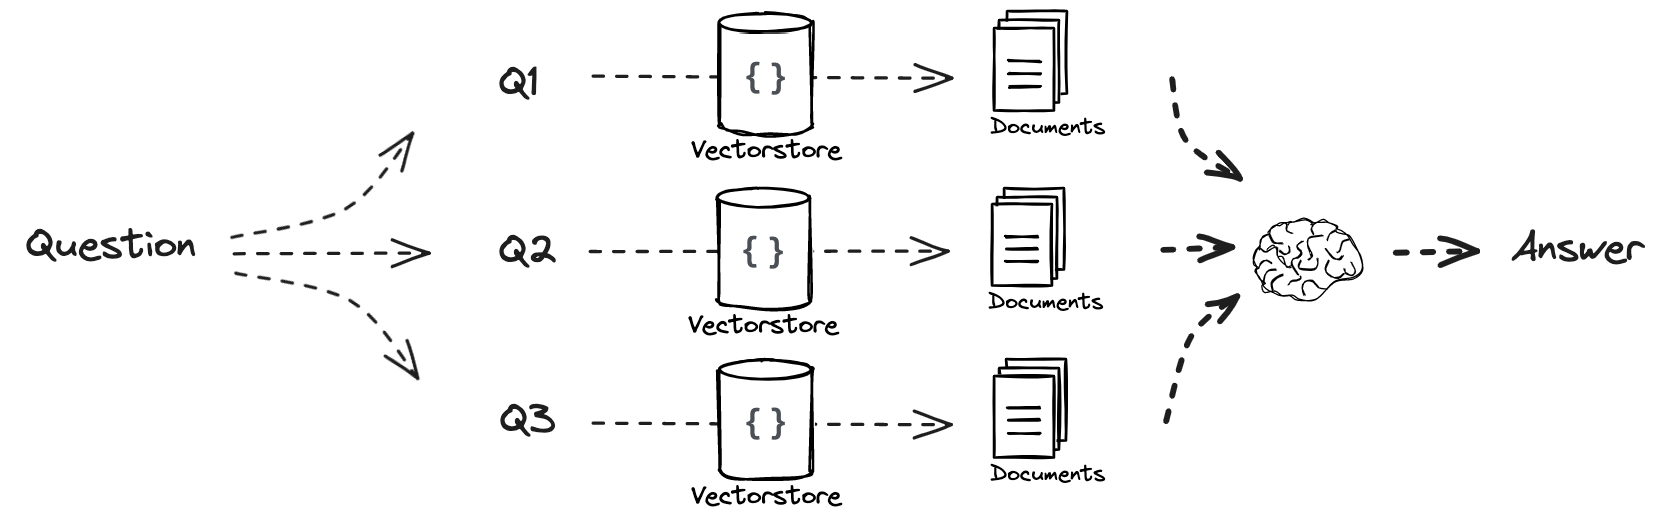

`with_structured_output(MultiQuery)` forces the LLM response into the Pydantic schema -
no newline-parsing of free text. First appearance of a pattern used heavily later
(query construction, routing).

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

from langchain_ollama import ChatOllama

llm = ChatOllama(model='gemma3:4b', temperature=0.7)

class MultiQuery(BaseModel):
    queries: List[str] = Field(description='5 alternative versions of the user query')

# Multi Query: Different Perspectives
template = """You are an AI language model assistant. Your task is to generate five 
different versions of the given user question to retrieve relevant documents from a vector 
database. By generating multiple perspectives on the user question, your goal is to help
the user overcome some of the limitations of the distance-based similarity search. 
Provide these alternative questions separated by newlines. Original question: {question}"""

structured_llm = llm.with_structured_output(MultiQuery)
prompt = ChatPromptTemplate.from_template(template)

generate_queries = prompt | structured_llm

question = "How does an operating system decide which process should get the CPU, and what are the major scheduling algorithms?"
queries = generate_queries.invoke({"question": question})

print(queries)



Dedup trick: `{doc.page_content: doc}` dict comprehension - identical chunks retrieved by
different query variants collapse into one, keeping first-seen order.

In [ ]:
# Similarity Search for the Multi-query in vector store and dedup the docs

all_docs = retreiver.batch(queries.queries)
dedup_docs = list({doc.page_content: doc for docs in all_docs for doc in docs}.values())
res = rag_chain(question=question, docs=dedup_docs)
res

## Technique 2 - RAG Fusion

Same expansion as Multi Query, different **merge strategy**:

- Multi Query: concatenate results + dedup (position = luck)
- RAG Fusion: **Reciprocal Rank Fusion** - documents ranked high across MANY query
variations bubble to the top mathematically

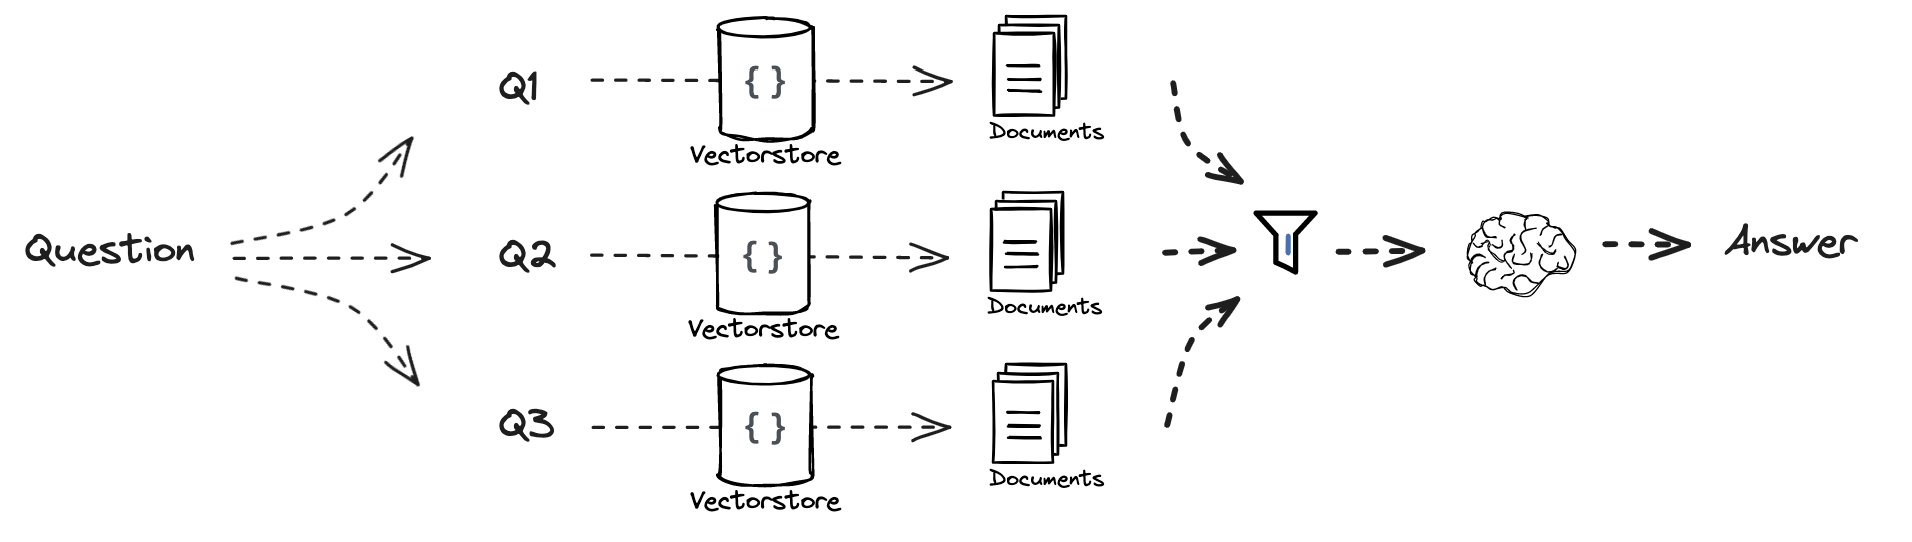

Identical query-generation setup as Multi Query - only what happens AFTER retrieval differs.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

from langchain_ollama import ChatOllama

llm = ChatOllama(model='gemma3:4b', temperature=0.7)

class MultiQuery(BaseModel):
    queries: List[str] = Field(description='5 alternative versions of the user query')

# Multi Query: Different Perspectives
template = """You are an AI language model assistant. Your task is to generate five 
different versions of the given user question to retrieve relevant documents from a vector 
database. By generating multiple perspectives on the user question, your goal is to help
the user overcome some of the limitations of the distance-based similarity search. 
Provide these alternative questions separated by newlines. Original question: {question}"""

structured_llm = llm.with_structured_output(MultiQuery)
prompt = ChatPromptTemplate.from_template(template)

generate_queries = prompt | structured_llm

question = "Explain how fork() and exec() differ when creating or replacing a process, and describe the parent-child relationship involved."
queries = generate_queries.invoke({"question": question})

queries

RRF mechanics:
- For each result list, a doc at rank r earns `1 / (r + k)`, k=60 dampens the vote of top ranks
- Same doc appearing in several lists accumulates scores from EACH list
- Sort by accumulated score

Rank-based (not similarity-score-based) on purpose: scores are not comparable across queries,
positions are.

In [ ]:
# Similarity Search for the Multi-query in vector store and dedup the docs
from langchain_core.documents import Document
from typing import List

def reciprocal_rank_fusion(results: List[List[Document]], k:int=60) -> List[Document]:
    fused_scores = {}

    for docs in results:
        for rank, doc in enumerate(docs):
            content = doc.page_content

            if content not in fused_scores:
                fused_scores[content] = {"doc": doc, "score" : 0.0}

            fused_scores[content]["score"] = 1.0 / (rank + k)

    reranked = sorted(
        fused_scores.values(),
        key=lambda item: item["score"],
        reverse=True
    )

    return [item["doc"] for item in reranked]

res = retreiver.batch(queries.queries)
rrf_docs = reciprocal_rank_fusion(res)
res = rag_chain(question=question, docs=rrf_docs)
res


## Technique 3 - Decomposition (IR-CoT style)

**Problem:** multi-part questions retrieve poorly as one query - each part needs
different evidence.

**Idea:** break into sub-questions, answer them ONE BY ONE while feeding each
answer back as context for the next (interleaved retrieval + reasoning), then synthesize.

Opposite direction of Multi Query/Fusion: fewer, deeper queries instead of many parallel ones.

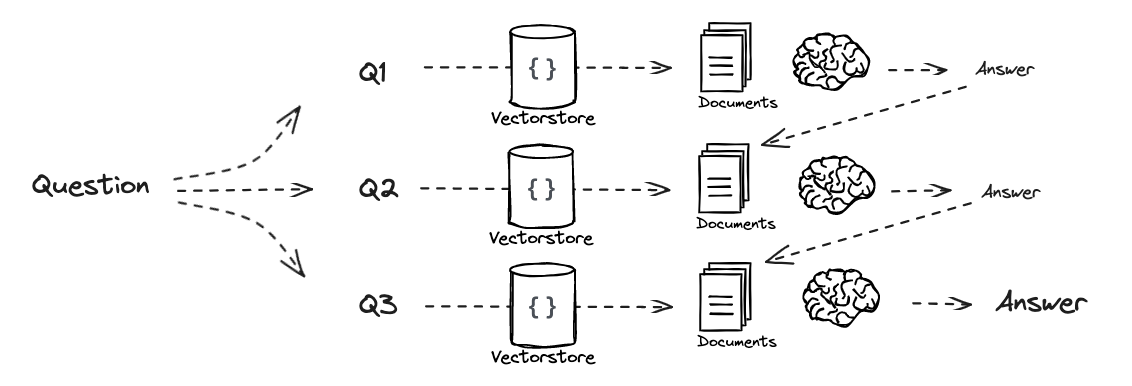

Reuses the same generation chain to produce sub-questions - the prompt says "five versions"
but here we treat them as decomposition parts. Works, though a dedicated decompose prompt
would be cleaner.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

from langchain_ollama import ChatOllama

llm = ChatOllama(model='gemma3:4b', temperature=0.7)

class MultiQuery(BaseModel):
    queries: List[str] = Field(description='5 alternative versions of the user query')

# Multi Query: Different Perspectives
template = """You are an AI language model assistant. Your task is to generate five 
different versions of the given user question to retrieve relevant documents from a vector 
database. By generating multiple perspectives on the user question, your goal is to help
the user overcome some of the limitations of the distance-based similarity search. 
Provide these alternative questions separated by newlines. Original question: {question}"""

structured_llm = llm.with_structured_output(MultiQuery)
prompt = ChatPromptTemplate.from_template(template)

generate_queries = prompt | structured_llm

question = "Suppose multiple threads modify the same variable concurrently. Explain why this can cause incorrect results, how this relates to a critical section, and how a mutex or semaphore can prevent the problem."
sub_questions = generate_queries.invoke({"question": question}).queries

print(sub_questions)


The interleaving loop - core of IR-CoT:

1. Retrieve docs for sub-question 1
2. Answer it using docs + running `qa_history`
3. Append Q&A to history; sub-question 2 now sees what was already learned

Each sub-answer builds on previous ones - that is why hard multi-part questions survive.

In [ ]:
qa_history = ""
sub_q_prompt = ChatPromptTemplate.from_template("""
Previous Q&A Context:
{history}

Retrieved Documents:
{context}

Answer this sub-question: {sub_question}
""")

sub_q_chain = sub_q_prompt | llm

for sub_q in sub_questions:

    docs = retreiver.invoke(sub_q)

    response = sub_q_chain.invoke({
        "history": qa_history if qa_history else "None",
        "context": docs,
        "sub_question": sub_q
    })

    qa_history += f"Q: {sub_q}\nA: {response.content}\n---\n"

qa_history

Final synthesis: only `qa_history` + original question go to the LLM - no raw docs.
All evidence flows through the intermediate answers.

In [ ]:
final_prompt = ChatPromptTemplate.from_template("""
Use the collected research history to answer the original user query directly.

Research History:
{history}

Original Query: {question}
""")

final_answer = (final_prompt | llm).invoke({
    "history" : qa_history,
    "question" : question
})

final_answer.content

## Technique 4 - Step-back Prompting

Decomposition zooms IN; step-back zooms OUT: paraphrase the specific question into
a generic, foundational one.

- Specific context answers the exact question
- Step-back context supplies background principles
- Both fed together to the final prompt

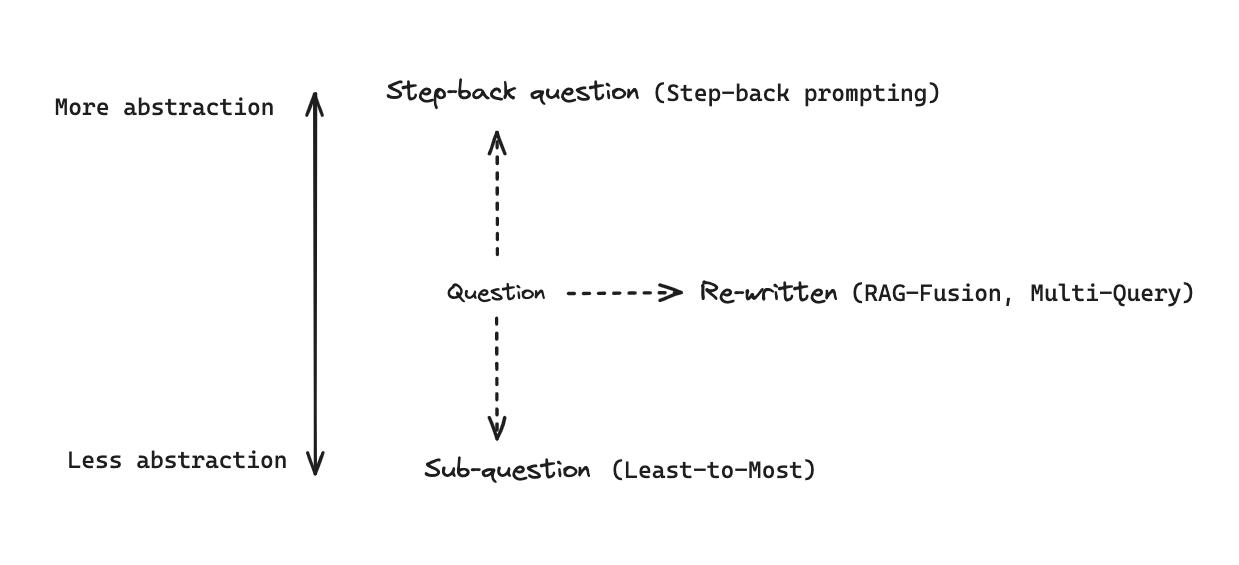

Few-shot setup: two hand-written input->step-back examples teach the transformation pattern;
`FewShotChatMessagePromptTemplate` injects them as chat messages before the real question.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser

llm = ChatOllama(model="gemma3:4b")

# Few Shot prompting
examples = [
    {
        "input": "Could the members of The Police perform lawful arrests?",
        "output": "What can the members of The Police do?",
    },
    {
        "input": "Jan Sindel's was born in what country?",
        "output": "What is Jan Sindel's personal history?",
    },
]

example_prompt = ChatPromptTemplate.from_messages([
    ("human", "{input}"),
    ("ai", "{output}")
])


fewshot_prompt = FewShotChatMessagePromptTemplate(
    examples=examples,
    example_prompt=example_prompt
)

stepback_template = """You are an expert at world knowledge. Your task is to step back and paraphrase a question to a more generic step-back question, which is easier to answer. Output only the question. Here are a few examples:
"""

stepback_prompt = ChatPromptTemplate.from_messages([
    (
        'system',
        stepback_template,
    ),
    fewshot_prompt,
    ("user", "{question}")
])

stepback_chain = stepback_prompt | llm | StrOutputParser()

question = "A process is running on the CPU when the operating system decides to stop it and give the CPU to another process. What is happening here, why does the operating system do this, and what information must be saved so that the original process can continue later?"
stepback_question = stepback_chain.invoke({"question": question})
stepback_question

LCEL dict-chains fan out IN PARALLEL:

- `itemgetter("question") | retreiver` -> specific context
- `stepback_chain | retreiver` -> foundational context
- both keys of the dict fill simultaneously, then feed one prompt

`itemgetter` just routes the original question untouched into a branch.

In [ ]:
from operator import itemgetter

response_prompt = ChatPromptTemplate.from_template("""
You are an expert of world knowledge. Answer the original question using the relevant context.

# Specific Context:
{normal_context}

# Foundational Context:
{step_back_context}

# Original Question:
{question}

# Answer:
""")

stepback_rag_chain = (
    {
        "normal_context" : itemgetter("question") | retreiver,
        "step_back_context" : stepback_chain | retreiver,
        "question" : itemgetter("question")
    }
    | response_prompt
    | llm
    | StrOutputParser()
)

stepback_rag_chain.invoke({
    "question": question
})

## Technique 5 - HyDE (Hypothetical Document Embeddings)

**Problem:** questions and documents live in different corners of embedding space
(question style vs document style).

**Idea:** ask the LLM to WRITE a fake answer passage, embed THAT, and search with it -
a document matches documents better than a question does.

The hallucinated content itself is never shown to the model answering - only used for search.

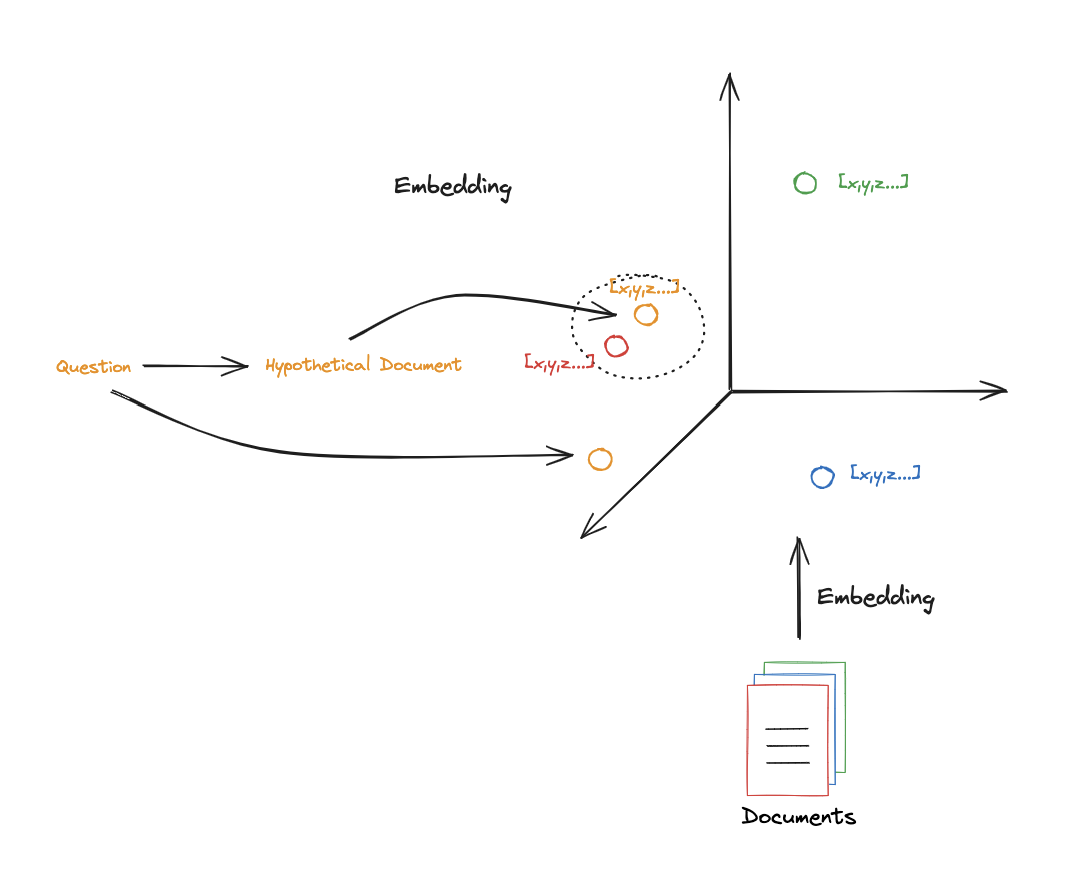

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama

llm = ChatOllama(model='gemma3:4b', temperature=0.7) # Higher temp encourages rich hypothetical docs

hyde_template = """Please write a scientific passage answering the question. 
Provide detailed explanations and technical terminology. Do not provide any fillers but output only the passage

Question: {question}
Passage:"""

hyde_prompt = ChatPromptTemplate.from_template(hyde_template)
hyde_chain = hyde_prompt | llm | StrOutputParser()

question="What happens to a process when it is waiting for an I/O operation, and how does the operating system eventually allow that process to continue executing?"

# hyde_docs = hyde_chain.invoke({"question":question})
# hyde_docs

The whole trick in one line: `hyde_chain | retreiver`.
The retriever receives the HYPOTHETICAL passage, embeds it, and searches -
the returned docs are real; the fake passage never reaches the answer prompt.

In [ ]:
retrieval_chain = hyde_chain | retreiver
retrieved_docs = retrieval_chain.invoke({"question":question})
retrieved_docs

In [ ]:
response_prompt = ChatPromptTemplate.from_template("""
Answer the user's question using ONLY the provided real context.

Context:
{context}

Question: {question}
Answer:"""
)

rag_chain = response_prompt | llm | StrOutputParser()

res = rag_chain.invoke({
    "context":retrieved_docs,
    "question": question
})
res